# Phase 1 Project
## Project Overview
### Identifying Low-Risk Aircraft for New Aviation Division Launch
For this project will use data cleaning, imputation, analysis, and visualization to generate insights for a business stakeholder.

## Business Understanding

### 1. Project Purpose

This project is a strategic initiative to support the company's expansion into the aviation industry. The primary purpose is to conduct a comprehensive analysis of aircraft risk profiles to identify and recommend the most suitable low-risk aircraft for the new aviation division's initial fleet. This analysis will provide the necessary data and insights to mitigate the significant risks associated with aircraft acquisition and operation, thereby ensuring a stable and successful launch of the new business venture.

### 2. Problem Statement

The company is entering the aviation sector with a limited understanding of the inherent risks, which include, but are not limited to, accident rates, operational complexity, aircraft damage potential, and the human cost of incidents. A lack of data-driven insights in this area could lead to sub-optimal purchasing decisions, resulting in financial losses, operational inefficiencies, and significant safety liabilities. The problem is to transform raw aviation incident data into actionable intelligence that quantifies these risks and guides the selection of a low-risk, high-reliability aircraft portfolio.

### 3. Project Scope

#### This project will focus on the following key areas:

 * Data Analysis: Utilizing the provided "Aviation_Data.csv" dataset, the project will analyze historical aviation incidents to assess risk factors.

 * Risk Factor Quantification: Key risk factors such as accident frequency, aircraft damage severity, and human injury rates will be quantified and benchmarked across different aircraft makes and models.

 * Aircraft Filtering: The analysis will be filtered to focus on aircraft types relevant to commercial and private enterprises, excluding categories like amateur-built or military aircraft.

 * Risk Profile Generation: A comprehensive risk profile will be developed for each significant aircraft make and model, considering accident severity, operational context (e.g., phase of flight, weather conditions), and human impact.

 * Recommendation & Actionable Insights: The project will culminate in a set of clear, actionable recommendations for the head of the new aviation division, identifying specific aircraft makes and models that represent the lowest overall risk for initial acquisition. The report will explain the rationale behind these recommendations, highlighting key risk mitigation strategies.
 

## Key Business Questions to Address:

1. What are the primary risk factors associated with aircraft ownership and operation (e.g., accident rates, )?

3. How can these risk factors be quantified or assessed for different aircraft types?

4. Which specific aircraft models exhibit the lowest overall risk profile based on a comprehensive evaluation of these factors?

5. What are the key characteristics of these low-risk aircraft that make them suitable for the company's initial ventures?

6. What actionable insights and recommendations can be provided to the head of the aviation division to guide their aircraft purchasing

   decisions?

## Data Understanding
The data sources for this analysis will be pulled from the National Transportation Safety Board that includes aviation accident data from 1962 to 2023 about civil aviation accidents and selected incidents in the United States and international waters.
The data is contained in a csv file "Aviation_Data.csv"

### 1. Loading the Data with Pandas
In the cell below, we:

  * Import and alias pandas as pd
  * Import and alias numpy as np
  * Import and alias seaborn as sns
  * Import and alias matplotlib.pyplot as plt
  * Set Matplotlib visualizations to display inline in the notebook

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("Aviation_Data.csv", low_memory=False )
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


### 2. Famializing with the Data
   * Understanding the dimensionality of the dataset
   * Investigating what type of data it contains, and the data types used to store it
   * Discovering how missing values are encoded, and how many there are
   * Getting a feel for what information it does and doesn't contain

In [3]:
df.shape

(90348, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

From the information above we can deduce that: most of the items are objects and only 5 out of the 30 columns are floats and Event.Date and Publication.Date are objects instead of datetime.

In [5]:
df.isnull().sum()

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40216
Airport.Name              37644
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2841
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8555
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7843
Publication.Date          16689
dtype: i

In [6]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [7]:
df.columns = [col.replace(".", "_") for col in df.columns]
df.columns

Index(['Event_Id', 'Investigation_Type', 'Accident_Number', 'Event_Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport_Code',
       'Airport_Name', 'Injury_Severity', 'Aircraft_damage',
       'Aircraft_Category', 'Registration_Number', 'Make', 'Model',
       'Amateur_Built', 'Number_of_Engines', 'Engine_Type', 'FAR_Description',
       'Schedule', 'Purpose_of_flight', 'Air_carrier', 'Total_Fatal_Injuries',
       'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured',
       'Weather_Condition', 'Broad_phase_of_flight', 'Report_Status',
       'Publication_Date'],
      dtype='object')

In [8]:
df['Aircraft_damage'].value_counts()

Aircraft_damage
Substantial    64148
Destroyed      18623
Minor           2805
Unknown          119
Name: count, dtype: int64

In [9]:
df['Injury_Severity'].value_counts()

Injury_Severity
Non-Fatal     67357
Fatal(1)       6167
Fatal          5262
Fatal(2)       3711
Incident       2219
              ...  
Fatal(270)        1
Fatal(60)         1
Fatal(43)         1
Fatal(143)        1
Fatal(230)        1
Name: count, Length: 109, dtype: int64

In [10]:
df['Aircraft_Category'].value_counts()

Aircraft_Category
Airplane             27617
Helicopter            3440
Glider                 508
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 14
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

In [11]:
df['Make'].value_counts()

Make
Cessna             22227
Piper              12029
CESSNA              4922
Beech               4330
PIPER               2841
                   ...  
Leonard Walters        1
Maule Air Inc.         1
Motley Vans            1
Perlick                1
ROYSE RALPH L          1
Name: count, Length: 8237, dtype: int64

In [12]:
df['Model'].value_counts()

Model
152              2367
172              1756
172N             1164
PA-28-140         932
150               829
                 ... 
GC-1-A              1
737-3S3             1
MBB-BK117-B2        1
GLASSAIR GL25       1
M-8 EAGLE           1
Name: count, Length: 12318, dtype: int64

In [13]:
df['Purpose_of_flight'].value_counts()

Purpose_of_flight
Personal                     49448
Instructional                10601
Unknown                       6802
Aerial Application            4712
Business                      4018
Positioning                   1646
Other Work Use                1264
Ferry                          812
Aerial Observation             794
Public Aircraft                720
Executive/corporate            553
Flight Test                    405
Skydiving                      182
External Load                  123
Public Aircraft - Federal      105
Banner Tow                     101
Air Race show                   99
Public Aircraft - Local         74
Public Aircraft - State         64
Air Race/show                   59
Glider Tow                      53
Firefighting                    40
Air Drop                        11
ASHO                             6
PUBS                             4
PUBL                             1
Name: count, dtype: int64

In [14]:
df['Weather_Condition'].value_counts()

Weather_Condition
VMC    77303
IMC     5976
UNK      856
Unk      262
Name: count, dtype: int64

In [15]:
df['Broad_phase_of_flight'].value_counts()

Broad_phase_of_flight
Landing        15428
Takeoff        12493
Cruise         10269
Maneuvering     8144
Approach        6546
Climb           2034
Taxi            1958
Descent         1887
Go-around       1353
Standing         945
Unknown          548
Other            119
Name: count, dtype: int64

In [16]:
df['Amateur_Built'].value_counts()

Amateur_Built
No     80312
Yes     8475
Name: count, dtype: int64

In [17]:
df['Amateur_Built'].unique()

array(['No', 'Yes', nan], dtype=object)

## 3. Data Cleaning and Filtering

In [18]:
# Filtering out only airplanes 
# The business problem mentions "airplanes for commercial and private enterprises"
# Also we will filter out the Amateur Built for that purpose
df_filtered = df[df['Aircraft_Category'] == 'Airplane'].copy()
df_filtered = df_filtered[df_filtered['Amateur_Built']!= "Yes"]
df_filtered

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Purpose_of_flight,Air_carrier,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,NaN,Air Canada,NaN,NaN,1.0,44.0,VMC,Climb,Probable Cause,19-09-2017
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,Personal,NaN,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,Business,NaN,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,0.0,1.0,0.0,IMC,Cruise,Probable Cause,02-01-1983
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,Personal,NaN,1.0,0.0,0.0,0.0,IMC,Takeoff,Probable Cause,02-01-1983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90328,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,14-12-2022
90332,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,Personal,SKY WEST AVIATION INC TRUSTEE,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90335,20221219106475,Accident,WPR23LA069,2022-12-15,"Wichita, KS",United States,373829N,0972635W,ICT,WICHITA DWIGHT D EISENHOWER NT,...,NaN,NaN,0.0,0.0,0.0,1.0,NaN,NaN,NaN,19-12-2022
90336,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,Personal,GERBER RICHARD E,0.0,1.0,0.0,0.0,VMC,NaN,NaN,23-12-2022


In [19]:
df_filtered['Amateur_Built'].value_counts()

Amateur_Built
No    24417
Name: count, dtype: int64

In [20]:
df_filtered['Aircraft_Category'].value_counts()

Aircraft_Category
Airplane    24434
Name: count, dtype: int64

In [21]:
# Convert Event_Date to datetime
df_filtered['Event_Date'] = pd.to_datetime(df_filtered['Event_Date'], errors='coerce')

In [22]:
# deal with duplicates if any
df_filtered.duplicated().value_counts()

False    24434
Name: count, dtype: int64

#### Further cleaning on key columns
Filling missing values in injury or damage columns is essential before performing calculations on them. 
For categorical data, some of them already have unknown as a unique variable, makes sense in this case and it will prevent errors.

In [23]:
df_filtered.isna().sum()

Event_Id                      0
Investigation_Type            0
Accident_Number               0
Event_Date                    0
Location                      7
Country                       7
Latitude                   5259
Longitude                  5265
Airport_Code               8948
Airport_Name               8449
Injury_Severity             813
Aircraft_damage            1274
Aircraft_Category             0
Registration_Number         216
Make                          3
Model                        18
Amateur_Built                17
Number_of_Engines          2562
Engine_Type                3967
FAR_Description             480
Schedule                  21486
Purpose_of_flight          3695
Air_carrier               14078
Total_Fatal_Injuries       2779
Total_Serious_Injuries     2862
Total_Minor_Injuries       2578
Total_Uninjured             729
Weather_Condition          2990
Broad_phase_of_flight     18635
Report_Status              4663
Publication_Date           2014
dtype: i

In [24]:
df_filtered['Total_Fatal_Injuries'].describe()

count    21655.000000
mean         0.692912
std          6.304978
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        295.000000
Name: Total_Fatal_Injuries, dtype: float64

In [25]:
df_filtered['Total_Serious_Injuries'].describe()

count    21572.000000
mean         0.304144
std          2.222139
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        161.000000
Name: Total_Serious_Injuries, dtype: float64

In [26]:
df_filtered['Total_Minor_Injuries'].describe()

count    21856.000000
mean         0.237875
std          1.689570
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        200.000000
Name: Total_Minor_Injuries, dtype: float64

In [27]:
df_filtered['Total_Uninjured'].describe()

count    23705.000000
mean         7.080574
std         33.725437
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max        588.000000
Name: Total_Uninjured, dtype: float64

In [28]:
# Fill missing injury/damage values with 0 or a sensible default
injury_cols = ['Total_Fatal_Injuries', 'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured']
for col in injury_cols:
    df_filtered[col] = df_filtered[col].fillna(0).astype(int)

In [29]:
# filling the missing values of the categorical data  with 'unknown'
aircraft_related_cols = ['Injury_Severity', 'Aircraft_damage', 'Make', 'Model', 'Amateur_Built',
       'Weather_Condition', 'Broad_phase_of_flight']

In [30]:
for cols in aircraft_related_cols:
    df_filtered[cols] = df_filtered[cols].fillna('Unknown')

# 4. Analyze Key Risk Factors
## Accident Rates by Make and Model
This is fundamental. In order to know which aircraft types are involved in more incidents.

In [31]:
#Investigating the unique counts of make and model
df_filtered['Make'].value_counts().head(20)

Make
CESSNA                4867
Cessna                3578
PIPER                 2803
Piper                 1901
BOEING                1037
BEECH                 1018
Beech                  667
Boeing                 278
MOONEY                 238
CIRRUS DESIGN CORP     218
AIR TRACTOR INC        217
AIRBUS                 215
Mooney                 179
Grumman                172
BELLANCA               158
AERONCA                149
MAULE                  144
Air Tractor            135
EMBRAER                123
Bellanca               123
Name: count, dtype: int64

In [32]:
df_filtered['Make'] = df_filtered['Make'].str.title()

In [33]:
# Asserting that we dont have the same make with different spellings
df_filtered['Make'].value_counts().head(20)

Make
Cessna                8445
Piper                 4704
Beech                 1685
Boeing                1315
Mooney                 417
Bellanca               281
Grumman                249
Airbus                 244
Maule                  232
Aeronca                227
Air Tractor            224
Cirrus Design Corp     220
Air Tractor Inc        219
Champion               169
Luscombe               163
Embraer                155
Stinson                145
Cirrus                 137
North American         118
Mcdonnell Douglas      113
Name: count, dtype: int64

In [34]:
make_incidents = df_filtered['Make'].value_counts().head(10)
make_incidents

Make
Cessna      8445
Piper       4704
Beech       1685
Boeing      1315
Mooney       417
Bellanca     281
Grumman      249
Airbus       244
Maule        232
Aeronca      227
Name: count, dtype: int64


--- A. Top 10 Aircraft Makes by Incident Count ---
Make
Cessna      8445
Piper       4704
Beech       1685
Boeing      1315
Mooney       417
Bellanca     281
Grumman      249
Airbus       244
Maule        232
Aeronca      227
Name: count, dtype: int64


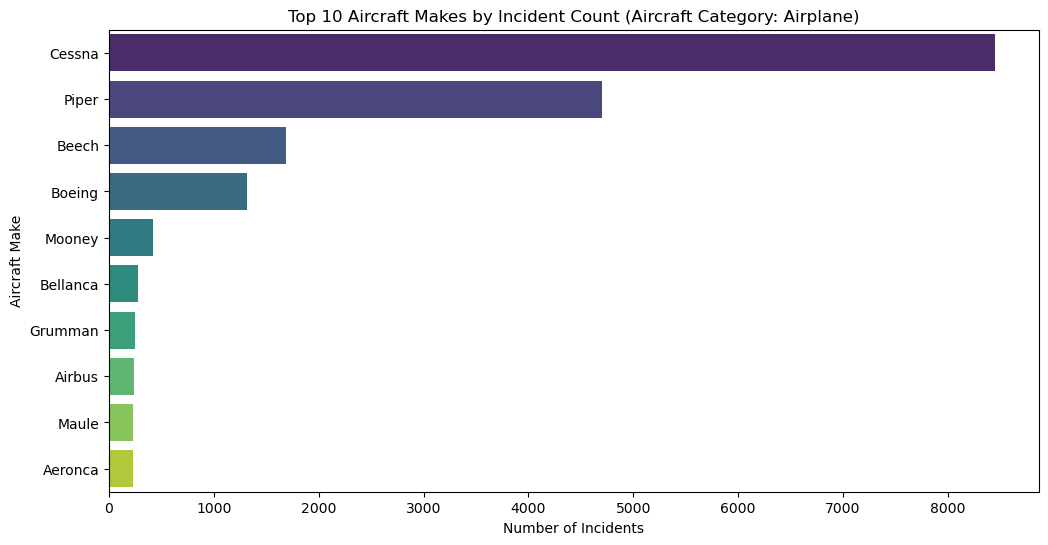

In [35]:
# A. Accident Rates by Make and Model
# This is fundamental. We need to know which aircraft types are involved in more incidents.
# Note: Without total fleet size/flight hours, this is a count of incidents, not a true rate.
# However, a higher count still implies higher exposure to incidents in this dataset.

print("\n--- A. Top 10 Aircraft Makes by Incident Count ---")
make_incidents = df_filtered['Make'].value_counts().head(10)
print(make_incidents)

plt.figure(figsize=(12, 6))
sns.barplot(x=make_incidents.values, y=make_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title('Top 10 Aircraft Makes by Incident Count (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Make')
plt.show()

In [36]:
top_make_10 = make_incidents.index[0]
top_make_10

'Cessna'

In [37]:
top_5_makes = df_filtered['Make'].value_counts().head(5).index
top_5_makes 

Index(['Cessna', 'Piper', 'Beech', 'Boeing', 'Mooney'], dtype='object', name='Make')

In [38]:
df_filtered['Total_Injuries'] = df_filtered['Total_Fatal_Injuries'] + df_filtered['Total_Serious_Injuries'] + df_filtered['Total_Minor_Injuries']

In [39]:
df_filtered

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Air_carrier,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date,Total_Injuries
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,Air Canada,0,0,1,44,VMC,Climb,Probable Cause,19-09-2017,1
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,NaN,0,0,0,2,VMC,Takeoff,Probable Cause,01-01-1982,0
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,NaN,0,0,0,2,IMC,Landing,Probable Cause,01-01-1982,0
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,NaN,0,0,1,0,IMC,Cruise,Probable Cause,02-01-1983,1
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,NaN,1,0,0,0,IMC,Takeoff,Probable Cause,02-01-1983,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90328,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NaN,0,0,0,1,Unknown,Unknown,NaN,14-12-2022,0
90332,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,SKY WEST AVIATION INC TRUSTEE,0,0,0,1,VMC,Unknown,NaN,27-12-2022,0
90335,20221219106475,Accident,WPR23LA069,2022-12-15,"Wichita, KS",United States,373829N,0972635W,ICT,WICHITA DWIGHT D EISENHOWER NT,...,NaN,0,0,0,1,Unknown,Unknown,NaN,19-12-2022,0
90336,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,GERBER RICHARD E,0,1,0,0,VMC,Unknown,NaN,23-12-2022,1


In [40]:
df_filtered['Total_Injuries'] = df_filtered['Total_Fatal_Injuries'] + df_filtered['Total_Serious_Injuries'] + df_filtered['Total_Minor_Injuries']

In [41]:
total_injuries_by_make = df_filtered.groupby('Make')['Total_Injuries'].sum().nlargest(10)
total_injuries_by_make

Make
Cessna               6347
Boeing               5026
Piper                3673
Beech                1890
Airbus               1559
Embraer               501
Mcdonnell Douglas     459
Airbus Industrie      417
Mooney                404
De Havilland          244
Name: Total_Injuries, dtype: int64


--- B. Top 10 Aircraft Models by Incident Count (Requires filtering by Make) ---
Top 10 Models for Cessna:
Model
172     866
152     448
182     344
172N    314
172S    276
150     255
180     237
172M    217
172P    167
140     132
Name: count, dtype: int64


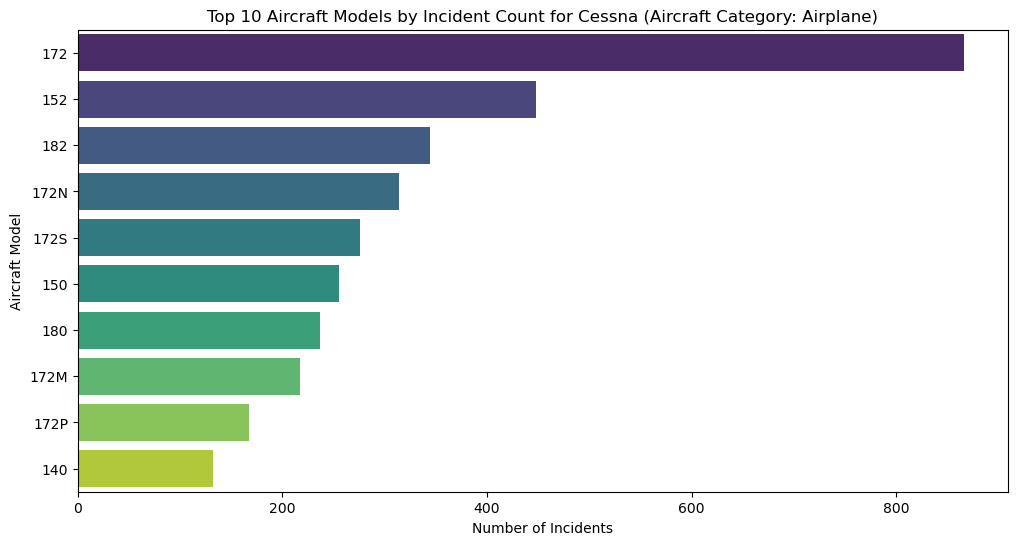

In [42]:
print("\n--- B. Top 10 Aircraft Models by Incident Count (Requires filtering by Make) ---")
# Example: Let's look at models for the top make (e.g., CESSNA)
top_make = make_incidents.index[0] # Get the most frequent make
model_incidents = df_filtered[df_filtered['Make'] == top_make]['Model'].value_counts().head(10)
print(f"Top 10 Models for {top_make}:")
print(model_incidents)

plt.figure(figsize=(12, 6))
sns.barplot(x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

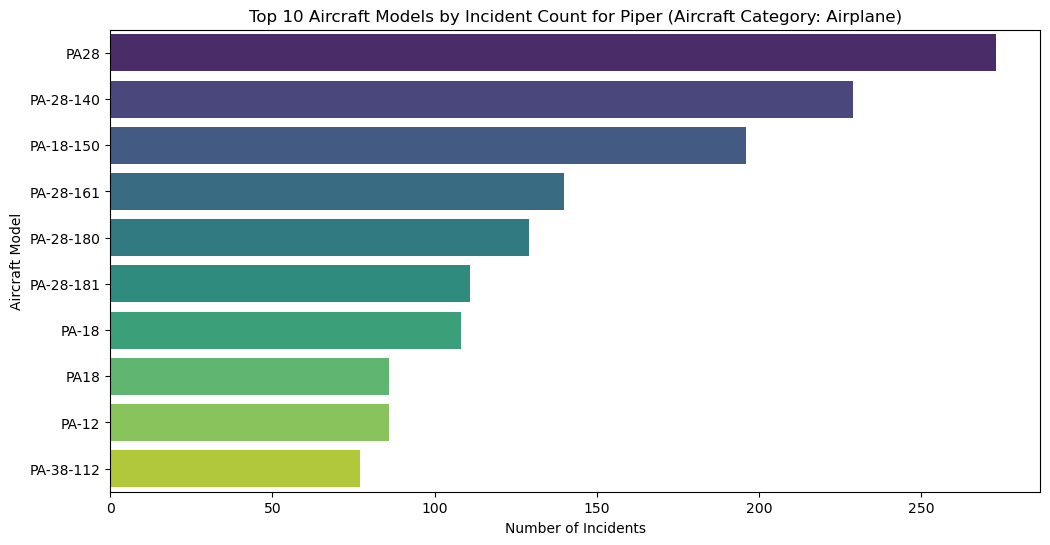

In [43]:
top_make_1 = make_incidents.index[1] # Get the most frequent make
model_incidents = df_filtered[df_filtered['Make'] == top_make_1]['Model'].value_counts().head(10)


plt.figure(figsize=(12, 6))
sns.barplot(x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis', legend=False)
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make_1} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

In [44]:
# To clean all entries with Fatal and group them all together
df_filtered['Injury_Severity'] = df_filtered['Injury_Severity'].apply(lambda x: 'Fatal' if 'Fatal' in str(x) else x)
df_filtered['Injury_Severity'].value_counts()

Injury_Severity
Fatal          23112
Unknown          813
Incident         238
Minor            146
Serious          108
Unavailable       17
Name: count, dtype: int64

In [45]:
# Get the top 10 makes
top_10_makes = df_filtered['Make'].value_counts().head(10).index

# Filter the DataFrame to include only the top 10 makes
df_top_10_makes = df_filtered[df_filtered['Make'].isin(top_10_makes)]

# Create a contingency table of make and injury severity


In [46]:
make_injury_alternative = df_top_10_makes.groupby(['Make', 'Injury_Severity']).size().unstack(fill_value=0)
display(make_injury_alternative)

Injury_Severity,Fatal,Incident,Minor,Serious,Unavailable,Unknown
Make,,,,,,
Aeronca,219,2,3,3,0,0
Airbus,132,5,0,1,0,106
Beech,1641,18,3,7,1,15
Bellanca,277,0,2,2,0,0
Boeing,821,63,5,7,6,413
Cessna,8255,26,58,26,3,77
Grumman,246,2,0,1,0,0
Maule,231,0,1,0,0,0
Mooney,406,2,2,4,0,3


In [47]:
# Create a contingency table of make and injury severity
make_injury = pd.crosstab(df_top_10_makes['Make'], df_top_10_makes['Injury_Severity'])
make_injury

Injury_Severity,Fatal,Incident,Minor,Serious,Unavailable,Unknown
Make,,,,,,
Aeronca,219,2,3,3,0,0
Airbus,132,5,0,1,0,106
Beech,1641,18,3,7,1,15
Bellanca,277,0,2,2,0,0
Boeing,821,63,5,7,6,413
Cessna,8255,26,58,26,3,77
Grumman,246,2,0,1,0,0
Maule,231,0,1,0,0,0
Mooney,406,2,2,4,0,3


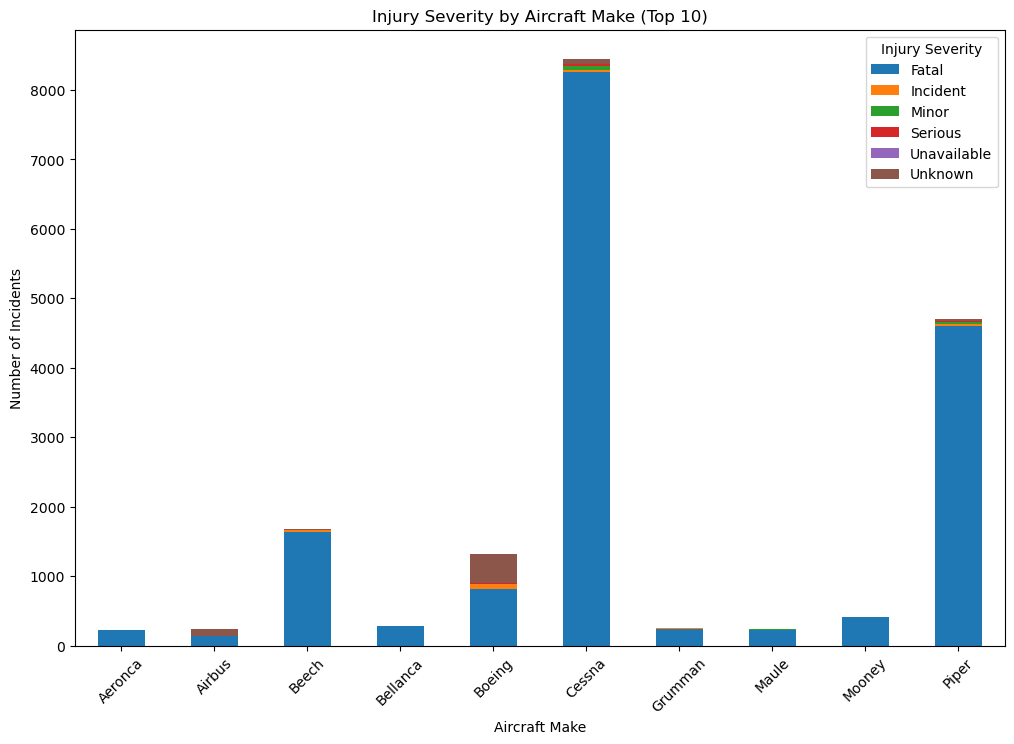

In [48]:
# Create the stacked bar chart
make_injury.plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Injury Severity by Aircraft Make (Top 10)')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend(title='Injury Severity')
plt.show()

In [49]:
# Create a combined injury column for easier overall severity assessment
df_filtered['Has_Fatal_Injury'] = df_filtered['Total_Fatal_Injuries'] > 0
df_filtered['Has_Serious_Injury'] = df_filtered['Total_Serious_Injuries'] > 0

In [50]:
df_filtered.head()

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date,Total_Injuries,Has_Fatal_Injury,Has_Serious_Injury
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,0,1,44,VMC,Climb,Probable Cause,19-09-2017,1,False,False
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,0,0,2,VMC,Takeoff,Probable Cause,01-01-1982,0,False,False
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,0,0,2,IMC,Landing,Probable Cause,01-01-1982,0,False,False
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,0,1,0,IMC,Cruise,Probable Cause,02-01-1983,1,False,False
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,0,0,0,IMC,Takeoff,Probable Cause,02-01-1983,1,True,False


In [51]:
# Defining a numerical severity score for Aircraft_damage for easier comparison
damage_mapping = {
    'Destroyed': 3,
    'Substantial': 2,
    'Minor': 1,
    'Unknown': 0,}
df_filtered['Damage_Score'] = df_filtered['Aircraft_damage'].map(damage_mapping)

In [52]:
df_filtered.head()

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date,Total_Injuries,Has_Fatal_Injury,Has_Serious_Injury,Damage_Score
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,42.445277,-70.758333,NaN,NaN,...,1,44,VMC,Climb,Probable Cause,19-09-2017,1,False,False,2
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,NaN,NaN,BLACKBURN AG STRIP,...,0,2,VMC,Takeoff,Probable Cause,01-01-1982,0,False,False,2
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,NaN,NaN,N58,HANOVER,...,0,2,IMC,Landing,Probable Cause,01-01-1982,0,False,False,2
12,20020917X02148,Accident,FTW82FRJ07,1982-01-02,"HOMER, LA",United States,NaN,NaN,NaN,NaN,...,1,0,IMC,Cruise,Probable Cause,02-01-1983,1,False,False,3
13,20020917X02134,Accident,FTW82FRA14,1982-01-02,"HEARNE, TX",United States,NaN,NaN,T72,HEARNE MUNICIPAL,...,0,0,IMC,Takeoff,Probable Cause,02-01-1983,1,True,False,3


In [53]:
# 3. Quantifying Risk Factors for Different Aircraft Types (Make and Model)

print("--- Quantifying Risk Factors for Aircraft Types ---")

# Let's focus on the top N makes/models to avoid excessively long outputs
top_n_makes = 20 # Adjust as needed
top_n_models_per_make = 5 # Adjust as needed

# A. Accident Frequency (Count of Incidents)
# This is the most basic measure of risk: how often is an aircraft type involved in an incident?
print("\n--- A. Incident Frequency by Aircraft Make ---")
make_incident_counts = df_filtered['Make'].value_counts().nlargest(top_n_makes)
print(make_incident_counts)


--- Quantifying Risk Factors for Aircraft Types ---

--- A. Incident Frequency by Aircraft Make ---
Make
Cessna                8445
Piper                 4704
Beech                 1685
Boeing                1315
Mooney                 417
Bellanca               281
Grumman                249
Airbus                 244
Maule                  232
Aeronca                227
Air Tractor            224
Cirrus Design Corp     220
Air Tractor Inc        219
Champion               169
Luscombe               163
Embraer                155
Stinson                145
Cirrus                 137
North American         118
Mcdonnell Douglas      113
Name: count, dtype: int64


In [63]:
df_filtered['Make'].value_counts().head(30)

Make
Cessna                      8445
Piper                       4704
Beech                       1685
Boeing                      1315
Mooney                       417
Bellanca                     281
Grumman                      249
Airbus                       244
Maule                        232
Aeronca                      227
Air Tractor                  224
Cirrus Design Corp           220
Air Tractor Inc              219
Champion                     169
Luscombe                     163
Embraer                      155
Stinson                      145
Cirrus                       137
North American               118
Mcdonnell Douglas            113
Taylorcraft                  110
Aero Commander               106
Dehavilland                   95
De Havilland                  88
Aviat Aircraft Inc            76
Socata                        75
Diamond Aircraft Ind Inc      74
Aviat                         70
Ercoupe                       66
Bombardier Inc                65
Name:

In [64]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Airbus' if 'Airbus' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                         8445
Piper                          4704
Beech                          1685
Boeing                         1315
Mooney                          417
                               ... 
Aviocar Casa                      1
Loehle Aircraft Corp              1
Interplane S R O                  1
Piaggio Aero Industries Spa       1
Orlican S R O                     1
Name: count, Length: 1126, dtype: int64

In [65]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Air Tractor' if 'Air Tractor' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                         8445
Piper                          4704
Beech                          1685
Boeing                         1315
Air Tractor                     450
                               ... 
Aviocar Casa                      1
Loehle Aircraft Corp              1
Interplane S R O                  1
Piaggio Aero Industries Spa       1
Orlican S R O                     1
Name: count, Length: 1123, dtype: int64

In [66]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Cirrus' if 'Cirrus' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                         8445
Piper                          4704
Beech                          1685
Boeing                         1315
Air Tractor                     450
                               ... 
Us Light Aircraft Corp            1
Rolladen-Schneider                1
Central Ohio Dragonfly Club       1
Chevrier, Armand                  1
Orlican S R O                     1
Name: count, Length: 1119, dtype: int64

In [67]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Aviat' if 'Aviat' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                           8445
Piper                            4704
Beech                            1685
Boeing                           1315
Air Tractor                       450
                                 ... 
Liberty Aerospace Incorporate       1
Lester Robert E                     1
Bombardier Learjet Corp.            1
New Kolb Aircraft Co                1
Orlican S R O                       1
Name: count, Length: 1079, dtype: int64

In [68]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Aeronca' if 'Aeronca' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                          8445
Piper                           4704
Beech                           1685
Boeing                          1315
Air Tractor                      450
                                ... 
Bombardier Learjet Corp.           1
New Kolb Aircraft Co               1
Nelson Sydney/Nelson Diann         1
T Bird Golden Circle Air Inc       1
Orlican S R O                      1
Name: count, Length: 1076, dtype: int64

In [69]:
df_filtered['Make'] = df_filtered['Make'].apply(lambda x: 'Cessna' if 'Cessna' in str(x) else x)
df_filtered['Make'].value_counts()

Make
Cessna                        8502
Piper                         4704
Beech                         1685
Boeing                        1315
Air Tractor                    450
                              ... 
Lester Robert E                  1
Bombardier Learjet Corp.         1
New Kolb Aircraft Co             1
Nelson Sydney/Nelson Diann       1
Orlican S R O                    1
Name: count, Length: 1066, dtype: int64

In [70]:
# Top 10 Aircraft Models by Incident Count which we will filter by Make
# Example: Let's look at models for the top Make(10) (e.g., Cessna, Boeing, Airbus and Aviat)
top_make = make_incidents.index[0] # Get the most frequent make
top_make_4 = make_incidents.index[3] # Boeing
top_make_8 = make_incidents.index[7] # Airbus
top_make_10 = make_incidents.index[9] # Aviat
model_incidents = df_filtered[df_filtered['Make'] == top_make]['Model'].value_counts().head(10)


plt.figure(figsize=(12, 6)
sns.barplot( x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis',legend=False )
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

SyntaxError: invalid syntax (3464745796.py, line 11)

In [54]:
# B. Accident Frequency by Model (for top Makes)
print(f"\n--- B. Incident Frequency by Aircraft Model (Top {top_n_models_per_make} models per top {top_n_makes} Makes) ---")
model_incident_counts = {}
for make in make_incident_counts.index:
    models_in_make = df_filtered[df_filtered['Make'] == make]['Model'].value_counts().nlargest(top_n_models_per_make)
    if not models_in_make.empty:
        model_incident_counts[make] = models_in_make
        print(f"\nModels for {make}:")
        print(models_in_make)


--- B. Incident Frequency by Aircraft Model (Top 5 models per top 20 Makes) ---

Models for Cessna:
Model
172     866
152     448
182     344
172N    314
172S    276
Name: count, dtype: int64

Models for Piper:
Model
PA28         273
PA-28-140    229
PA-18-150    196
PA-28-161    140
PA-28-180    129
Name: count, dtype: int64

Models for Beech:
Model
A36     175
58       83
C23      71
35       56
V35B     40
Name: count, dtype: int64

Models for Boeing:
Model
737    403
777     76
747     68
767     60
757     42
Name: count, dtype: int64

Models for Mooney:
Model
M20J    106
M20C     64
M20E     49
M20F     47
M20K     28
Name: count, dtype: int64

Models for Bellanca:
Model
7GCBC     61
7ECA      37
17-30A    33
8GCBC     29
8KCAB     27
Name: count, dtype: int64

Models for Grumman:
Model
G-164A    57
G164      33
G-164B    22
G-164     22
AA5       14
Name: count, dtype: int64

Models for Airbus:
Model
A320    79
A330    31
A321    20
A319    13
A300     9
Name: count, dtype: int

/var/folders/_k/pq6hlhp525nfwz0yj93j4rkh0000gn/T/ipykernel_80152/112948665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_incident_counts.values, y=make_incident_counts.index, palette='viridis')


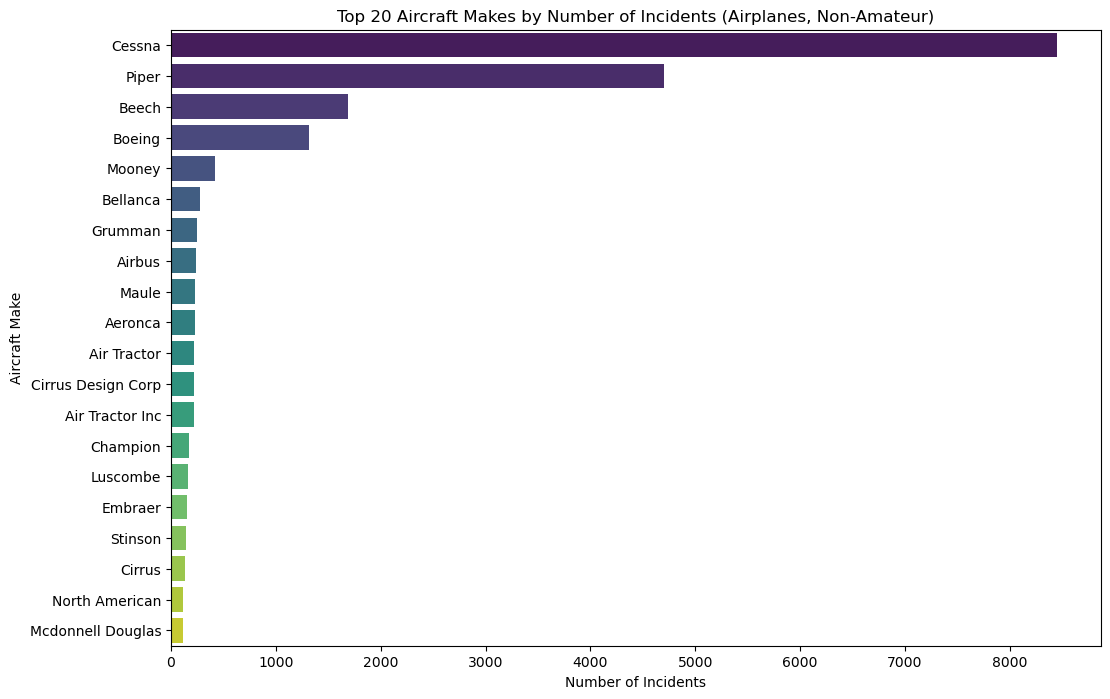

In [55]:
# Visualize top Makes by incident count
plt.figure(figsize=(12, 8))
sns.barplot(x=make_incident_counts.values, y=make_incident_counts.index, palette='viridis')
plt.title(f'Top {top_n_makes} Aircraft Makes by Number of Incidents (Airplanes, Non-Amateur)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Make')
plt.show()

In [56]:
# C. Severity of Aircraft Damage
# Calculate average damage score and distribution of damage types per aircraft type

print("\n--- C. Average Aircraft Damage Severity by Make (Higher score = more severe) ---")
make_avg_damage = df_filtered.groupby('Make')['Damage_Score'].mean().nlargest(top_n_makes)
print(make_avg_damage)

print(f"\n--- D. Proportion of 'Destroyed' Damage by Make (Top {top_n_makes}) ---")
make_destroyed_prop = df_filtered[df_filtered['Aircraft_damage'] == 'Destroyed'].groupby('Make').size() / df_filtered.groupby('Make').size()
make_destroyed_prop = make_destroyed_prop.fillna(0).nlargest(top_n_makes) * 100 # Convert to percentage
print(make_destroyed_prop)


--- C. Average Aircraft Damage Severity by Make (Higher score = more severe) ---
Make
3Xtrim                        3.0
Aerofab Inc.                  3.0
Aeronca Champ                 3.0
Aerospool                     3.0
Aerostar                      3.0
Aficionado                    3.0
Aircraft Mfg & Dvlpmt Co      3.0
Airvan                        3.0
Alon Aircoupe                 3.0
American Eurocopter           3.0
Ang                           3.0
Angel Aircraft Corporation    3.0
Antenor Velazco               3.0
Aviamilano                    3.0
Avions Robin                  3.0
Bartels                       3.0
Bedecorp Llc                  3.0
Beech Aircraft Co.            3.0
Beech Aircraft Corp           3.0
Believer                      3.0
Name: Damage_Score, dtype: float64

--- D. Proportion of 'Destroyed' Damage by Make (Top 20) ---
Make
3Xtrim                        100.0
Aerofab Inc.                  100.0
Aeronca Champ                 100.0
Aerospool              

/var/folders/_k/pq6hlhp525nfwz0yj93j4rkh0000gn/T/ipykernel_80152/990988315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_destroyed_prop.values, y=make_destroyed_prop.index, palette='Reds_d')


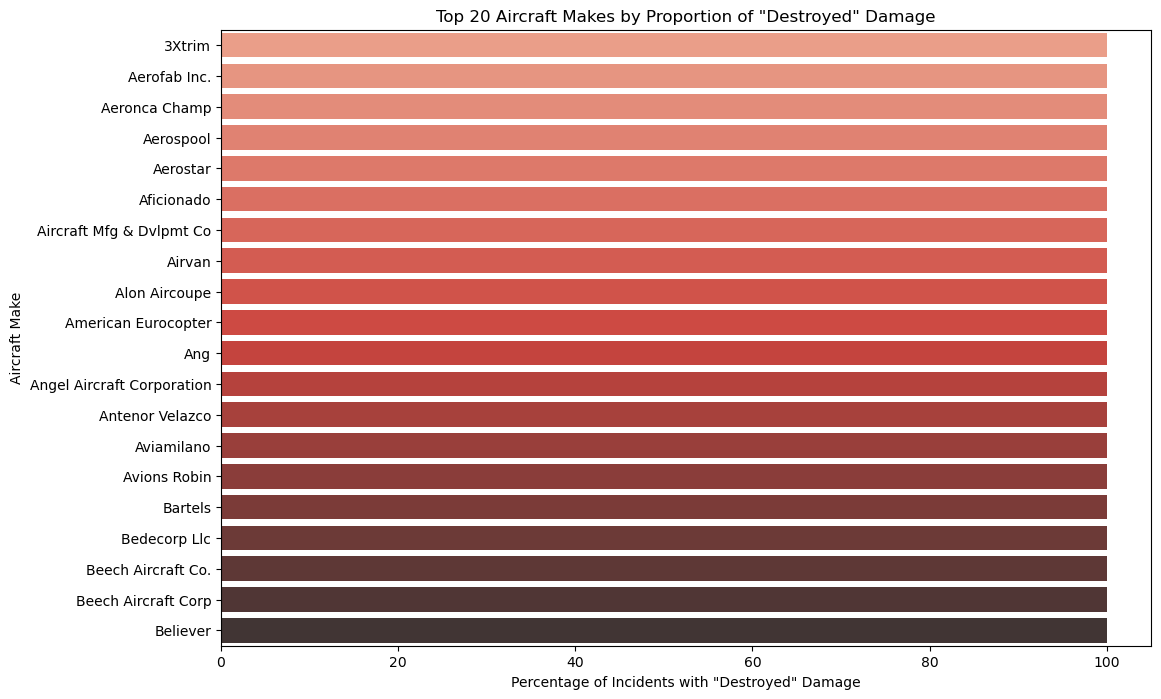

In [57]:
# Visualize Proportion of 'Destroyed' Damage by Make
plt.figure(figsize=(12, 8))
sns.barplot(x=make_destroyed_prop.values, y=make_destroyed_prop.index, palette='Reds_d')
plt.title(f'Top {top_n_makes} Aircraft Makes by Proportion of "Destroyed" Damage')
plt.xlabel('Percentage of Incidents with "Destroyed" Damage')
plt.ylabel('Aircraft Make')
plt.show()


In [71]:
# Top 10 Aircraft Models by Incident Count which we will filter by Make
# Example: Let's look at models for the top Make(10) (e.g., Cessna, Boeing, Airbus and Aviat)
top_make = make_incidents.index[0] # Get the most frequent make
top_make_4 = make_incidents.index[3] # Boeing
top_make_8 = make_incidents.index[7] # Airbus
top_make_10 = make_incidents.index[9] # Aviat
model_incidents = df_filtered[df_filtered['Make'] == top_make]['Model'].value_counts().head(10)


plt.figure(figsize=(12, 6)
sns.barplot( x=model_incidents.values, y=model_incidents.index, hue=make_incidents.index, palette='viridis',legend=False )
plt.title(f'Top 10 Aircraft Models by Incident Count for {top_make} (Aircraft Category: Airplane)')
plt.xlabel('Number of Incidents')
plt.ylabel('Aircraft Model')
plt.show()

SyntaxError: invalid syntax (3464745796.py, line 11)

In [58]:
# E. Human Impact (Fatalities and Injuries)
# Calculate average fatalities/injuries and proportion of incidents with injuries

print("\n--- F. Average Fatalities per Incident by Make ---")
make_avg_fatalities = df_filtered[df_filtered['Total_Fatal_Injuries'] > 0].groupby('Make')['Total_Fatal_Injuries'].mean().nlargest(top_n_makes)
# Or, if we want average across *all* incidents involving that make (including those with 0 fatalities)
# make_avg_fatalities = df_filtered.groupby('Make')['Total_Fatal_Injuries'].mean().nlargest(top_n_makes)
print(make_avg_fatalities)

print(f"\n--- G. Proportion of Incidents with Fatalities by Make (Top {top_n_makes}) ---")
make_fatality_prop = df_filtered[df_filtered['Has_Fatal_Injury']].groupby('Make').size() / df_filtered.groupby('Make').size()
make_fatality_prop = make_fatality_prop.fillna(0).nlargest(top_n_makes) * 100
print(make_fatality_prop)


--- F. Average Fatalities per Incident by Make ---
Make
Airbus                109.666667
Tupolev                89.000000
Airbus Industrie       88.000000
Antonov                71.000000
Boeing                 56.894737
Atr                    50.500000
Fokker                 42.666667
Sukhoi                 28.666667
Bombardier Inc         27.500000
Viking Air Limited     23.000000
Aviocar Casa           18.000000
Let                    13.500000
Curtis-Wright          13.000000
Embraer                12.269231
Bombardier             11.500000
Dornier                11.000000
British Aerospace      10.000000
Embraer Aircraft       10.000000
Textron Aviation       10.000000
Airvan                  9.000000
Name: Total_Fatal_Injuries, dtype: float64

--- G. Proportion of Incidents with Fatalities by Make (Top 20) ---
Make
3Xtrim                            100.0
Aero Vodochody Aero. Works        100.0
Aerofab                           100.0
Aerofab Inc                       100.0
Aerofa

/var/folders/_k/pq6hlhp525nfwz0yj93j4rkh0000gn/T/ipykernel_80152/2806367993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=make_fatality_prop.values, y=make_fatality_prop.index, palette='OrRd_d')


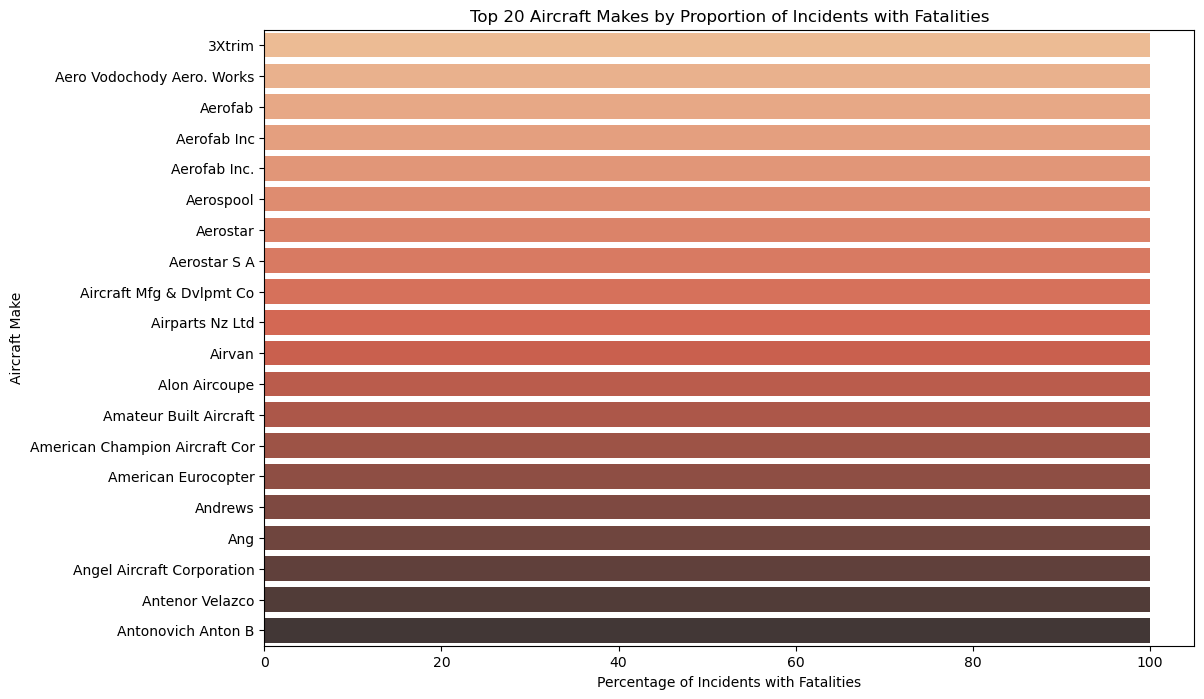

In [59]:
# Visualize Proportion of Incidents with Fatalities by Make
plt.figure(figsize=(12, 8))
sns.barplot(x=make_fatality_prop.values, y=make_fatality_prop.index, palette='OrRd_d')
plt.title(f'Top {top_n_makes} Aircraft Makes by Proportion of Incidents with Fatalities')
plt.xlabel('Percentage of Incidents with Fatalities')
plt.ylabel('Aircraft Make')
plt.show()